# Polymarket Market + Evidence Visual Analytics

This notebook combines market metadata and evidence retrieval outputs for:
- Date range analysis
- Topic analysis
- Evidence quality and source analysis
- Evidence-backed lookup for answering questions

In [1]:
# Optional: install missing packages
import importlib
import subprocess
import sys

for pkg in ["pandas", "numpy", "matplotlib", "seaborn", "plotly", "nbformat"]:
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

# Plotly rich output in notebooks depends on nbformat>=4.2
import nbformat
print("Dependencies are ready. nbformat=", nbformat.__version__)

Dependencies are ready. nbformat= 5.10.4


In [2]:
from pathlib import Path
import json
import re
from urllib.parse import urlparse

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.facecolor"] = "#f7f9fc"
plt.rcParams["figure.facecolor"] = "#ffffff"
PALETTE = ["#0f4c81", "#ff7f50", "#2a9d8f", "#e9c46a", "#6d597a", "#264653"]
TEMPLATE = "plotly_white"

In [4]:
# Data paths
ROOT = Path("..")
MARKET_CSV = ROOT / "data" / "outputs" / "final_markets_500.csv"
EVIDENCE_DIR = ROOT / "data" / "evidences"

assert MARKET_CSV.exists(), f"Missing: {MARKET_CSV}"
assert EVIDENCE_DIR.exists(), f"Missing: {EVIDENCE_DIR}"

# Load market data
market_df = pd.read_csv(MARKET_CSV, low_memory=False)

keep_cols = [
    "id", "question", "event_title", "topic", "quality_score",
    "startDateIso", "endDateIso", "createdAt",
    "volume", "liquidity", "p_yes", "p_no", "probability_bias",
    "description", "resolutionSource", "slug"
]
keep_cols = [c for c in keep_cols if c in market_df.columns]
market_df = market_df[keep_cols].copy()

market_df["id"] = market_df["id"].astype(str)
if "topic" in market_df.columns:
    market_df["topic"] = market_df["topic"].fillna("Unknown").astype(str)

for c in ["quality_score", "volume", "liquidity", "p_yes", "p_no", "probability_bias"]:
    if c in market_df.columns:
        market_df[c] = pd.to_numeric(market_df[c], errors="coerce")

for c in ["startDateIso", "endDateIso", "createdAt"]:
    if c in market_df.columns:
        market_df[c] = pd.to_datetime(market_df[c], errors="coerce", utc=True)

if "startDateIso" in market_df.columns and "endDateIso" in market_df.columns:
    market_df["market_duration_days"] = (market_df["endDateIso"] - market_df["startDateIso"]).dt.total_seconds() / 86400

# Load evidence data
meta_rows = []
ev_rows = []
pat = re.compile(r"row_(\d+)_(\d+)\.json$")

for fp in sorted(EVIDENCE_DIR.glob("row_*.json")):
    m = pat.search(fp.name)
    market_id_from_name = m.group(2) if m else None

    try:
        obj = json.loads(fp.read_text(encoding="utf-8"))
    except Exception:
        continue

    stats = obj.get("stats", {}) or {}
    market_id = str(obj.get("market_id", market_id_from_name))

    meta_rows.append({
        "market_id": market_id,
        "search_calls": pd.to_numeric(stats.get("search_calls"), errors="coerce"),
        "raw_result_count": pd.to_numeric(stats.get("raw_result_count"), errors="coerce"),
        "deduped_result_count": pd.to_numeric(stats.get("deduped_result_count"), errors="coerce"),
        "expanded_query_count": len(obj.get("expanded_queries", []) or []),
        "evidence_count": len(obj.get("evidences", []) or []),
    })

    for ev in obj.get("evidences", []) or []:
        url = ev.get("url")
        domain = None
        if isinstance(url, str) and url.strip():
            domain = urlparse(url).netloc.lower().replace("www.", "")

        ev_rows.append({
            "market_id": market_id,
            "title": ev.get("title"),
            "url": url,
            "domain": domain,
            "content": ev.get("content"),
            "score": pd.to_numeric(ev.get("score"), errors="coerce"),
            "query": ev.get("query")
        })

meta_df = pd.DataFrame(meta_rows)
evidence_df = pd.DataFrame(ev_rows)

ev_agg = evidence_df.groupby("market_id", as_index=False).agg(
    evidence_avg_score=("score", "mean"),
    evidence_max_score=("score", "max"),
    unique_domains=("domain", lambda s: s.dropna().nunique())
) if not evidence_df.empty else pd.DataFrame(columns=["market_id", "evidence_avg_score", "evidence_max_score", "unique_domains"])

analysis_df = market_df.merge(meta_df, left_on="id", right_on="market_id", how="left")
analysis_df = analysis_df.merge(ev_agg, left_on="id", right_on="market_id", how="left", suffixes=("", "_agg"))

for c in ["search_calls", "raw_result_count", "deduped_result_count", "expanded_query_count", "evidence_count", "unique_domains"]:
    if c in analysis_df.columns:
        analysis_df[c] = analysis_df[c].fillna(0)

for c in ["evidence_avg_score", "evidence_max_score"]:
    if c in analysis_df.columns:
        analysis_df[c] = analysis_df[c].fillna(0.0)

print("Markets:", len(analysis_df))
print("Evidence rows:", len(evidence_df))
analysis_df.head(3)

Markets: 500
Evidence rows: 13870


,id,question,event_title,topic,quality_score,startDateIso,endDateIso,createdAt,volume,liquidity,...,market_id,search_calls,raw_result_count,deduped_result_count,expanded_query_count,evidence_count,market_id_agg,evidence_avg_score,evidence_max_score,unique_domains
0,253657,SEC approves first spot Bitcoin ETF on Jan 10?,When will Bitcoin ETF be approved?,Crypto,3.600000,2024-01-08 00:00:00+00:00,2024-01-10 00:00:00+00:00,2024-01-08 18:19:39.740000+00:00,957594.506135,279370.95076,...,253657,3,30,22,3,22,253657,0.951477,0.999976,20
1,253986,Will 'Dune: Part Two' gross under $70m opening...,'Dune: Part Two' Opening Weekend Box Office,Crypto,3.581829,NaT,2024-03-01 00:00:00+00:00,2024-01-18 17:56:02.005000+00:00,196971.507771,110011.52974,...,253986,3,30,28,3,28,253986,0.971868,0.999949,13
2,253987,Will 'Dune: Part Two' gross between $70m-80m o...,'Dune: Part Two' Opening Weekend Box Office,Crypto,3.307317,NaT,2024-03-01 00:00:00+00:00,2024-01-18 17:56:02.061000+00:00,151219.431993,123793.35530,...,253987,3,30,24,3,24,253987,0.793599,0.933389,14


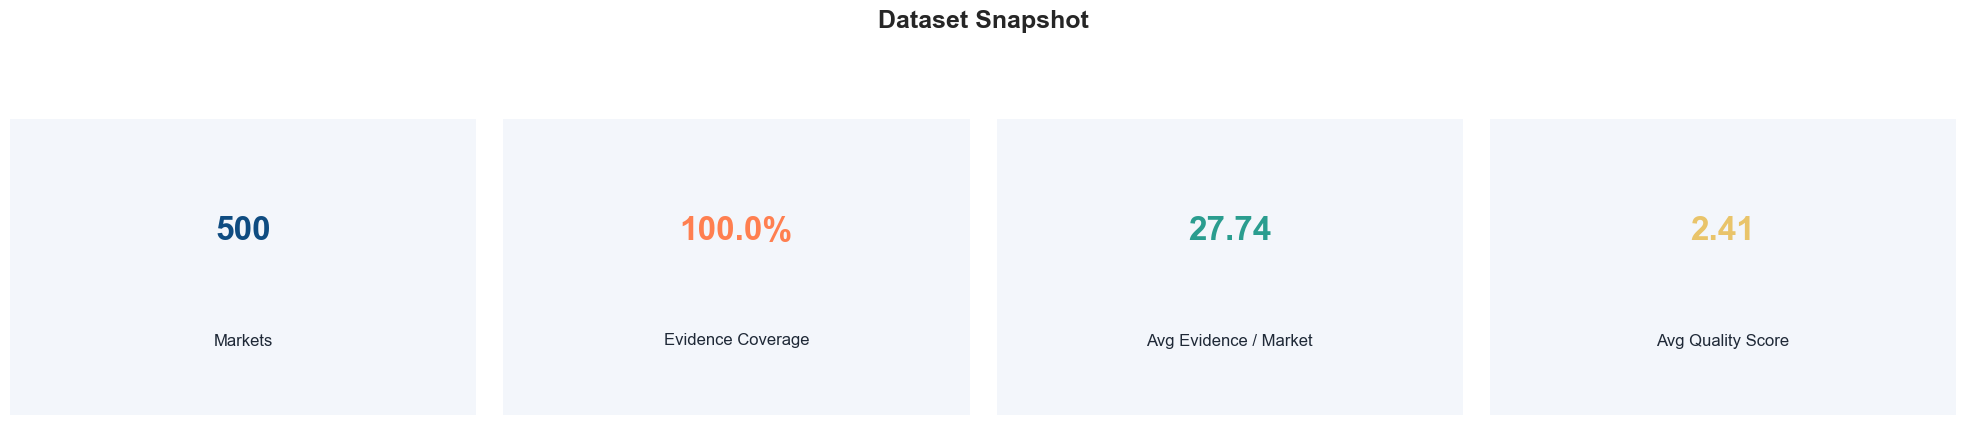

In [5]:
# KPI cards
n = len(analysis_df)
coverage = (analysis_df["evidence_count"] > 0).mean() if n else 0
avg_ev = analysis_df["evidence_count"].mean() if "evidence_count" in analysis_df.columns else 0
avg_q = analysis_df["quality_score"].mean() if "quality_score" in analysis_df.columns else np.nan

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
cards = [
    ("Markets", f"{n:,}"),
    ("Evidence Coverage", f"{coverage:.1%}"),
    ("Avg Evidence / Market", f"{avg_ev:.2f}"),
    ("Avg Quality Score", f"{avg_q:.2f}" if pd.notna(avg_q) else "N/A")
]

for ax, (title, value), color in zip(axes, cards, PALETTE + ["#334155"]):
    ax.set_facecolor("#f3f6fb")
    ax.text(0.5, 0.62, value, ha="center", va="center", fontsize=24, color=color, fontweight="bold")
    ax.text(0.5, 0.25, title, ha="center", va="center", fontsize=12, color="#1f2937")
    ax.set_xticks([])
    ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)

plt.suptitle("Dataset Snapshot", fontsize=18, fontweight="bold", y=1.08)
plt.tight_layout()
plt.show()

/var/folders/f9/6rf1w9652f1dqfvqrd_4plt40000gn/T/ipykernel_6583/2341028862.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  tmp["year_month"] = tmp[time_col].dt.to_period("M").astype(str)


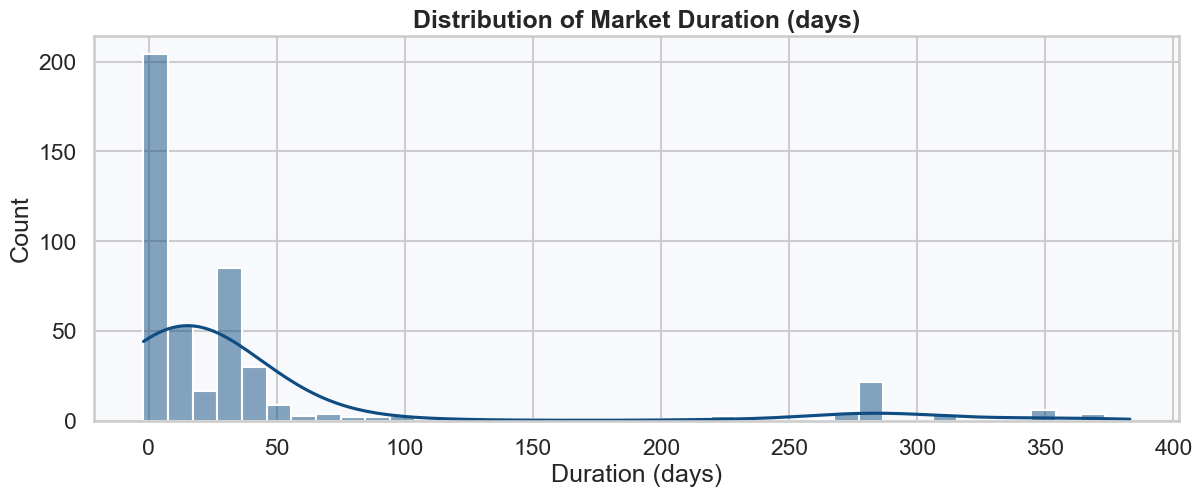

In [6]:
# Date range analysis + topic timeline
time_col = "startDateIso" if "startDateIso" in analysis_df.columns else "createdAt"
tmp = analysis_df.dropna(subset=[time_col]).copy()
tmp["year_month"] = tmp[time_col].dt.to_period("M").astype(str)

top_topics = tmp["topic"].value_counts().head(8).index.tolist()
tmp["topic_group"] = np.where(tmp["topic"].isin(top_topics), tmp["topic"], "Other")

ts = tmp.groupby(["year_month", "topic_group"], as_index=False).size()
fig = px.area(
    ts,
    x="year_month",
    y="size",
    color="topic_group",
    template=TEMPLATE,
    color_discrete_sequence=PALETTE,
    title="Market Count Over Time by Topic"
)
fig.update_layout(xaxis_title="Year-Month", yaxis_title="Market Count", legend_title="Topic")
fig.show()

if "market_duration_days" in analysis_df.columns:
    fig, ax = plt.subplots(figsize=(14, 5))
    sns.histplot(analysis_df["market_duration_days"].dropna(), bins=40, kde=True, color="#0f4c81", ax=ax)
    ax.set_title("Distribution of Market Duration (days)", fontweight="bold")
    ax.set_xlabel("Duration (days)")
    plt.show()

,topic,markets,avg_quality,avg_evidence_count,avg_evidence_score
1,Crypto,299,2.386830,28.090301,0.729985
8,Sports,110,2.313537,27.063636,0.794151
7,ScienceTech,45,2.364195,26.955556,0.725660
6,Politics,17,3.593421,27.470588,0.891640
0,Business,15,2.339333,28.200000,0.812318
5,Other,6,2.507469,28.166667,0.810764
2,Entertainment,3,2.358691,29.000000,0.790102
4,Macro,3,2.513421,26.000000,0.585403
3,Geopolitics,2,2.600001,28.500000,0.739336


/var/folders/f9/6rf1w9652f1dqfvqrd_4plt40000gn/T/ipykernel_6583/77492630.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=topic_stats.head(12), x="topic", y="markets", palette=PALETTE, ax=ax)
/var/folders/f9/6rf1w9652f1dqfvqrd_4plt40000gn/T/ipykernel_6583/77492630.py:12: UserWarning: 
The palette list has fewer values (6) than needed (9) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=topic_stats.head(12), x="topic", y="markets", palette=PALETTE, ax=ax)


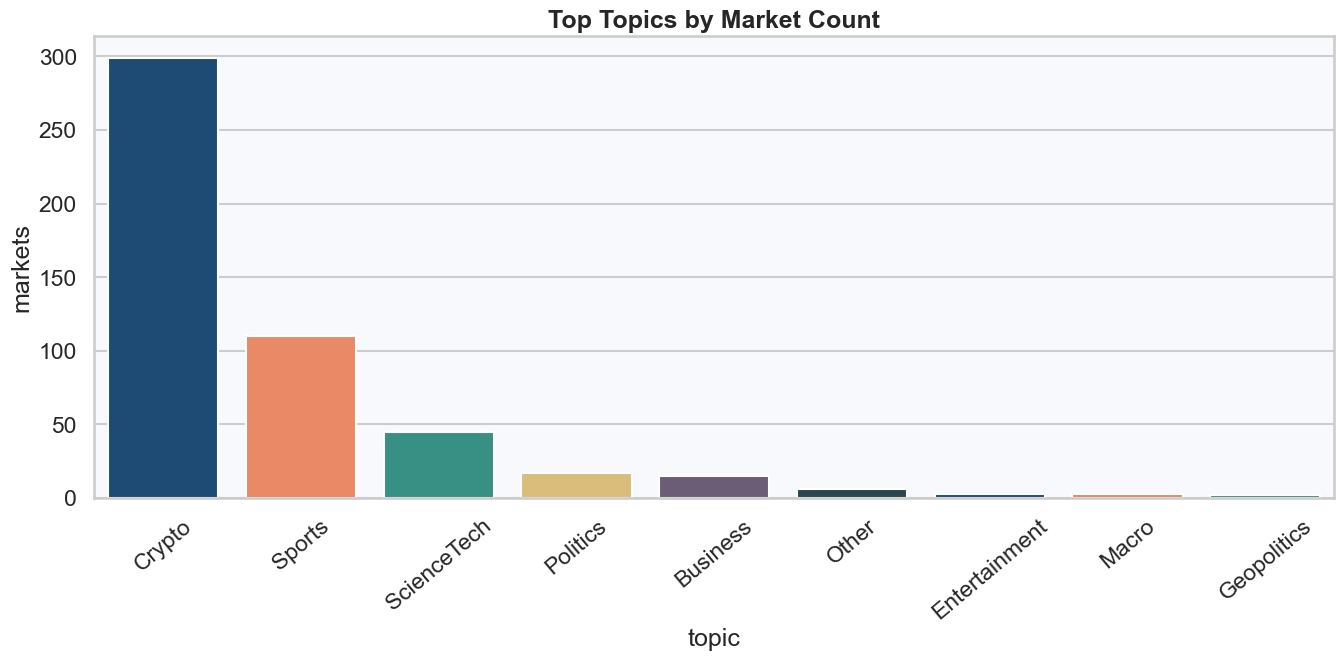

In [7]:
# Topic + evidence combined analysis
topic_stats = analysis_df.groupby("topic", as_index=False).agg(
    markets=("id", "count"),
    avg_quality=("quality_score", "mean"),
    avg_evidence_count=("evidence_count", "mean"),
    avg_evidence_score=("evidence_avg_score", "mean")
)
topic_stats = topic_stats.sort_values("markets", ascending=False)
display(topic_stats.head(12))

fig, ax = plt.subplots(figsize=(16, 6))
sns.barplot(data=topic_stats.head(12), x="topic", y="markets", palette=PALETTE, ax=ax)
ax.set_title("Top Topics by Market Count", fontweight="bold")
ax.tick_params(axis="x", rotation=40)
plt.show()

fig = px.scatter(
    topic_stats,
    x="avg_evidence_count",
    y="avg_quality",
    size="markets",
    color="avg_evidence_score",
    hover_name="topic",
    template=TEMPLATE,
    color_continuous_scale="Tealgrn",
    title="Topic Landscape: Evidence Depth vs Quality"
)
fig.show()

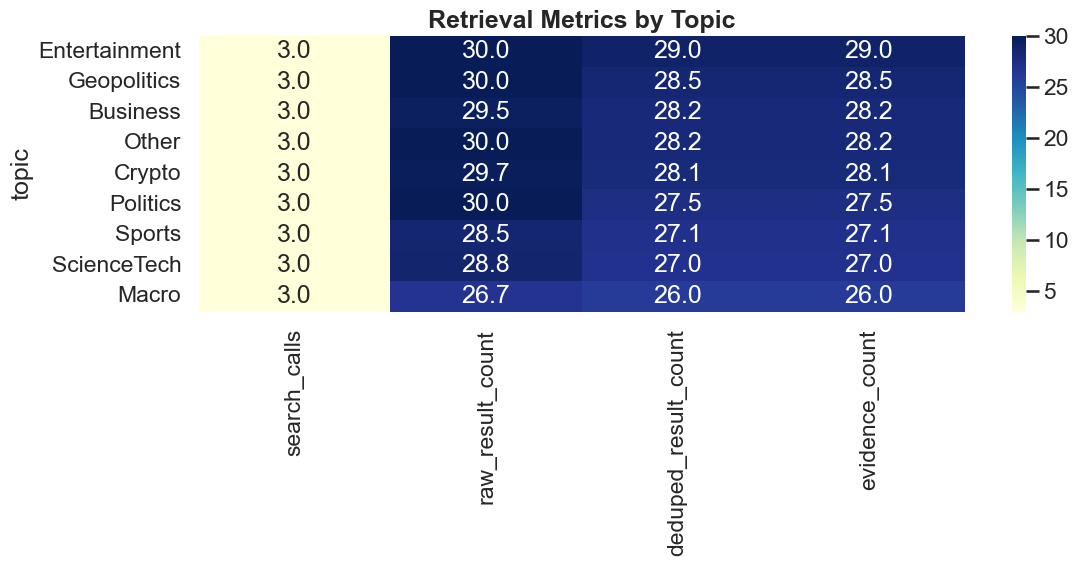

In [8]:
# Evidence source and retrieval diagnostics
if not evidence_df.empty:
    top_domains = evidence_df["domain"].fillna("unknown").value_counts().head(20).reset_index()
    top_domains.columns = ["domain", "count"]

    fig = px.bar(
        top_domains.sort_values("count"),
        x="count",
        y="domain",
        orientation="h",
        color="count",
        color_continuous_scale="Blues",
        template=TEMPLATE,
        title="Top Evidence Domains"
    )
    fig.show()

    retr = analysis_df[["topic", "search_calls", "raw_result_count", "deduped_result_count", "evidence_count"]].copy()
    retr = retr.groupby("topic", as_index=False).mean(numeric_only=True)
    retr = retr.sort_values("deduped_result_count", ascending=False).head(12)

    heat = retr.set_index("topic")
    plt.figure(figsize=(12, 6))
    sns.heatmap(heat, annot=True, fmt=".1f", cmap="YlGnBu")
    plt.title("Retrieval Metrics by Topic", fontweight="bold")
    plt.tight_layout()
    plt.show()

In [9]:
# Evidence-backed QA lookup helper
def evidence_lookup(query_text, top_k_markets=5, top_k_evidence=3, topic=None, start=None, end=None):
    q = str(query_text or "").lower().strip()
    tokens = [t for t in re.findall(r"[a-z0-9]{2,}", q)]

    df = analysis_df.copy()

    if topic is not None:
        df = df[df["topic"].astype(str).str.lower() == str(topic).lower()]

    if start is not None and "startDateIso" in df.columns:
        start_ts = pd.to_datetime(start, utc=True, errors="coerce")
        if pd.notna(start_ts):
            df = df[df["startDateIso"] >= start_ts]

    if end is not None and "endDateIso" in df.columns:
        end_ts = pd.to_datetime(end, utc=True, errors="coerce")
        if pd.notna(end_ts):
            df = df[df["endDateIso"] <= end_ts]

    text_cols = [c for c in ["question", "event_title", "description", "resolutionSource", "slug"] if c in df.columns]
    text_blob = df[text_cols].fillna("").agg(" ".join, axis=1).str.lower()

    if tokens:
        match = np.zeros(len(df), dtype=float)
        for t in tokens:
            match += text_blob.str.contains(re.escape(t), regex=True).astype(float).to_numpy()
    else:
        match = np.ones(len(df), dtype=float)

    bonus = np.log1p(df["evidence_count"].astype(float).fillna(0).to_numpy())
    df = df.copy()
    df["query_score"] = match + 0.25 * bonus + 0.1 * df["quality_score"].fillna(0).to_numpy()
    chosen = df.sort_values("query_score", ascending=False).head(top_k_markets)

    out = []
    for _, row in chosen.iterrows():
        mid = str(row["id"])
        sub = evidence_df[evidence_df["market_id"] == mid].copy()

        if not sub.empty:
            sub["rank"] = sub["score"].fillna(0)
            if tokens:
                eblob = sub[["title", "content", "query"]].fillna("").agg(" ".join, axis=1).str.lower()
                em = np.zeros(len(sub), dtype=float)
                for t in tokens:
                    em += eblob.str.contains(re.escape(t), regex=True).astype(float).to_numpy()
                sub["rank"] += em

        top_ev = sub.sort_values("rank", ascending=False).head(top_k_evidence) if not sub.empty else sub

        out.append({
            "market_id": mid,
            "topic": row.get("topic"),
            "question": row.get("question"),
            "query_score": row.get("query_score"),
            "evidence_count": row.get("evidence_count"),
            "top_evidence": top_ev[["title", "url", "score"]].to_dict(orient="records")
        })

    return out

# Example usage
results = evidence_lookup("bitcoin etf sec approval january 10", top_k_markets=3, top_k_evidence=2)
for i, item in enumerate(results, 1):
    print(f"[{i}] market_id={item['market_id']} | topic={item['topic']} | score={item['query_score']:.3f}")
    print("question:", item["question"])
    for ev in item["top_evidence"]:
        print("  -", ev.get("title"), "|", ev.get("url"), "| score=", ev.get("score"))
    print()

# Build answer table with evidence
QUERY = "government shutdown january 31"
rows = []
for r in evidence_lookup(QUERY, top_k_markets=8, top_k_evidence=1):
    top1 = r["top_evidence"][0] if r["top_evidence"] else {}
    rows.append({
        "market_id": r["market_id"],
        "topic": r["topic"],
        "question": r["question"],
        "query_score": r["query_score"],
        "evidence_score": top1.get("score"),
        "evidence_title": top1.get("title"),
        "evidence_url": top1.get("url")
    })

answer_df = pd.DataFrame(rows).sort_values("query_score", ascending=False)
display(answer_df)

[1] market_id=253657 | topic=Crypto | score=6.144
question: SEC approves first spot Bitcoin ETF on Jan 10?
  - SEC Approves Spot Bitcoin ETFs - Cambridge Associates | https://www.cambridgeassociates.com/insight/sec-approves-spot-bitcoin-etfs/ | score= 0.9999757
  - SEC Approves Exchange Listing Applications for Spot Bitcoin ETPs | https://www.regulatoryandcompliance.com/2024/01/sec-approves-exchange-listing-applications-for-spot-bitcoin-etps/ | score= 0.9999716

[2] market_id=253658 | topic=Crypto | score=6.124
question: SEC to NOT approve spot Bitcoin ETF by Jan 10?
  - SEC Approves Exchange Listing Applications for Spot Bitcoin ETPs | https://www.regulatoryandcompliance.com/2024/01/sec-approves-exchange-listing-applications-for-spot-bitcoin-etps/ | score= 0.9997154
  - SEC Approves Spot Bitcoin ETFs But Gensler Still Disapproves of ... | https://www.mintz.com/insights-center/viewpoints/2401/2024-01-12-sec-approves-spot-bitcoin-etfs-gensler-still-disapproves | score= 0.9996049

[3] ma

,market_id,topic,question,query_score,evidence_score,evidence_title,evidence_url
0,641250,Macro,Will the Government shutdown end by January 31?,5.092497,0.833880,2026 United States federal government shutdown...,https://en.wikipedia.org/wiki/2026_United_Stat...
1,254172,ScienceTech,Zvbear arrested before February?,4.110299,0.982691,Who Is Zvbear aka 'Zubear Abdi'? The Man Who L...,https://www.newsunzip.com/world/who-is-zvbear-...
2,254174,Crypto,Israel x Hamas ceasefire before March?,4.093051,0.994657,[PDF] Israel and Hamas Conflict In Brief: Over...,https://www.congress.gov/crs_external_products...
3,254219,Crypto,Will JUP be below $0.40 one day after airdrop?,3.121559,0.920911,"Jupiter Sets Date For JUP Airdrop, Teases Meme...",https://www.tradingview.com/news/cryptodaily:6...
4,252551,Crypto,Will there be a US government shutdown by Nove...,3.118497,0.980129,Congress passes funding bill to avert governme...,https://www.cnn.com/politics/live-news/federal...
5,254049,Macro,Will US attack Iran by February 15?,3.110299,0.623033,"Iran Update, February 15, 2024 | Critical Threats",https://www.criticalthreats.org/analysis/iran-...
6,253541,Crypto,Hamas lose power in Gaza before February?,3.110299,0.999713,Gaza Strip under Hamas - Wikipedia,https://en.wikipedia.org/wiki/Gaza_Strip_under...
7,251892,Crypto,Will there be a US government shutdown by Octo...,3.110299,0.839958,Congress enacts third stopgap to fund governme...,https://www.naco.org/news/congress-enacts-thir...
